# Chapter 8 RQ1 Results Visualization

This notebook generates the final empirical-result tables and figures for Research Question 1.

It focuses only on the supervised benchmark layer:
- `ethics`
- `normbank`
- `mfrc`

and uses the saved outputs in `results/metrics.csv`.

In [1]:
from __future__ import annotations

import io
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_DIR = REPO_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures" / "chapter8"
EXPORT_FIGURES = True

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)
print("RESULTS_DIR:", RESULTS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


REPO_ROOT: C:\Users\Ling Jun\Desktop\PSB\AI-ethics
RESULTS_DIR: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\results
FIGURES_DIR: C:\Users\Ling Jun\Desktop\PSB\AI-ethics\results\figures\chapter8


In [2]:
def save_current_figure(stem: str) -> None:
    if not EXPORT_FIGURES:
        return
    path = FIGURES_DIR / f"{stem}.png"
    plt.savefig(path, bbox_inches="tight")
    print("Saved:", path.relative_to(REPO_ROOT))


def annotate_bars(ax, fmt: str = "{:.3f}") -> None:
    for container in ax.containers:
        try:
            ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)
        except Exception:
            pass


def tidy_model(value: str) -> str:
    return str(value).replace("microsoft/", "")


def tidy_dataset(value: str) -> str:
    mapping = {"ethics": "ETHICS", "normbank": "NormBank", "mfrc": "MFRC"}
    return mapping.get(str(value), str(value))


## Load and Clean Saved Metrics

The saved `metrics.csv` contains duplicate runs and at least one merged-line formatting issue. The loader below repairs the obvious merged timestamp boundary and keeps the latest run per dataset-model pair.

In [3]:
def load_metrics_table(path: Path) -> pd.DataFrame:
    text = path.read_text(encoding="utf-8")
    text = re.sub(r"(?<=\d)(?=20\d{2}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2})", "\n", text)
    frame = pd.read_csv(io.StringIO(text))
    frame["timestamp_utc"] = pd.to_datetime(frame["timestamp_utc"], utc=True, errors="coerce")
    numeric_cols = [
        "accuracy",
        "macro_f1",
        "micro_f1",
        "balanced_accuracy",
        "mcc",
        "auroc_ovr",
        "pr_auc_macro",
        "brier_score",
        "ece_10bin",
    ]
    for col in numeric_cols:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    return frame.sort_values("timestamp_utc").reset_index(drop=True)


metrics_all = load_metrics_table(RESULTS_DIR / "metrics.csv")
metrics_latest = (
    metrics_all.sort_values("timestamp_utc")
    .groupby(["dataset", "model"], as_index=False)
    .tail(1)
    .sort_values(["dataset", "macro_f1"], ascending=[True, False])
    .reset_index(drop=True)
)

metrics_latest["dataset_label"] = metrics_latest["dataset"].map(tidy_dataset)
metrics_latest["model_label"] = metrics_latest["model"].map(tidy_model)

display(metrics_latest)


,timestamp_utc,dataset,model,train_limit,test_limit,accuracy,macro_f1,micro_f1,balanced_accuracy,mcc,auroc_ovr,pr_auc_macro,brier_score,ece_10bin,dataset_label,model_label
0,2026-03-25 13:55:02.526792+00:00,ethics,microsoft/deberta-v3-base,NaN,NaN,0.803269,0.796371,0.803269,0.798260,0.593122,0.882250,0.834122,3.399332e-01,1.524022e-01,ETHICS,deberta-v3-base
1,2026-03-25 13:08:06.007825+00:00,ethics,roberta-base,NaN,NaN,0.728130,0.718126,0.728130,0.719122,0.436424,0.802510,0.730483,4.580213e-01,2.039830e-01,ETHICS,roberta-base
2,2026-03-25 01:41:02.503166+00:00,ethics,bert-base-uncased,NaN,NaN,0.691272,0.679165,0.691272,0.679528,0.358364,0.755807,0.678521,4.945323e-01,2.122458e-01,ETHICS,bert-base-uncased
3,2026-03-25 01:41:02.529166+00:00,ethics,distilbert-base-uncased,NaN,NaN,0.679540,0.663625,0.679540,0.662491,0.327738,0.737041,0.661164,4.862180e-01,1.900300e-01,ETHICS,distilbert-base-uncased
4,2026-03-24 13:29:42.938494+00:00,ethics,tfidf_linearsvc,NaN,NaN,0.656551,0.651481,0.656551,0.658638,0.311204,0.705875,0.600461,4.357053e-01,5.119128e-02,ETHICS,tfidf_linearsvc
5,2026-03-24 13:29:23.546156+00:00,ethics,tfidf_logreg,NaN,NaN,0.657941,0.631902,0.657941,0.629959,0.270126,0.697338,0.592748,4.371517e-01,6.447532e-02,ETHICS,tfidf_logreg
6,2026-03-25 13:55:03.345430+00:00,mfrc,bert-base-uncased,NaN,NaN,0.704774,0.322013,0.704774,0.330171,0.459429,0.854489,0.427270,4.123271e-01,2.415373e-02,MFRC,bert-base-uncased
7,2026-03-25 13:55:04.069343+00:00,mfrc,distilbert-base-uncased,NaN,NaN,0.702176,0.303737,0.702176,0.313623,0.444420,0.849109,0.418650,4.206431e-01,1.624849e-02,MFRC,distilbert-base-uncased
8,2026-03-24 13:30:51.536063+00:00,mfrc,tfidf_logreg,NaN,NaN,0.663852,0.216903,0.663852,0.209050,0.307109,0.812225,0.372443,4.768987e-01,4.377475e-02,MFRC,tfidf_logreg
9,2026-03-20 08:29:43.204384+00:00,normbank,tfidf_linearsvc,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.932488e-06,1.578451e-04,NormBank,tfidf_linearsvc


## RQ1 Tables

In [4]:
rq1_table = metrics_latest[[
    "dataset_label",
    "model_label",
    "accuracy",
    "macro_f1",
    "balanced_accuracy",
    "mcc",
    "auroc_ovr",
    "ece_10bin",
]].copy().rename(columns={
    "dataset_label": "dataset",
    "model_label": "model",
})
display(rq1_table)

best_by_dataset = (
    metrics_latest.sort_values(["dataset", "macro_f1", "balanced_accuracy"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .loc[:, ["dataset_label", "model_label", "accuracy", "macro_f1", "balanced_accuracy", "mcc"]]
    .rename(columns={"dataset_label": "dataset", "model_label": "best_model"})
    .reset_index(drop=True)
)
display(best_by_dataset)


,dataset,model,accuracy,macro_f1,balanced_accuracy,mcc,auroc_ovr,ece_10bin
0,ETHICS,deberta-v3-base,0.803269,0.796371,0.798260,0.593122,0.882250,1.524022e-01
1,ETHICS,roberta-base,0.728130,0.718126,0.719122,0.436424,0.802510,2.039830e-01
2,ETHICS,bert-base-uncased,0.691272,0.679165,0.679528,0.358364,0.755807,2.122458e-01
3,ETHICS,distilbert-base-uncased,0.679540,0.663625,0.662491,0.327738,0.737041,1.900300e-01
4,ETHICS,tfidf_linearsvc,0.656551,0.651481,0.658638,0.311204,0.705875,5.119128e-02
5,ETHICS,tfidf_logreg,0.657941,0.631902,0.629959,0.270126,0.697338,6.447532e-02
6,MFRC,bert-base-uncased,0.704774,0.322013,0.330171,0.459429,0.854489,2.415373e-02
7,MFRC,distilbert-base-uncased,0.702176,0.303737,0.313623,0.444420,0.849109,1.624849e-02
8,MFRC,tfidf_logreg,0.663852,0.216903,0.209050,0.307109,0.812225,4.377475e-02
9,NormBank,tfidf_linearsvc,1.000000,1.000000,1.000000,1.000000,1.000000,1.578451e-04


,dataset,best_model,accuracy,macro_f1,balanced_accuracy,mcc
0,ETHICS,deberta-v3-base,0.803269,0.796371,0.798260,0.593122
1,MFRC,bert-base-uncased,0.704774,0.322013,0.330171,0.459429
2,NormBank,tfidf_linearsvc,1.000000,1.000000,1.000000,1.000000


## Cross-Dataset Comparison Figures

Saved: results\figures\chapter8\rq1_cross_dataset_macro_f1.png


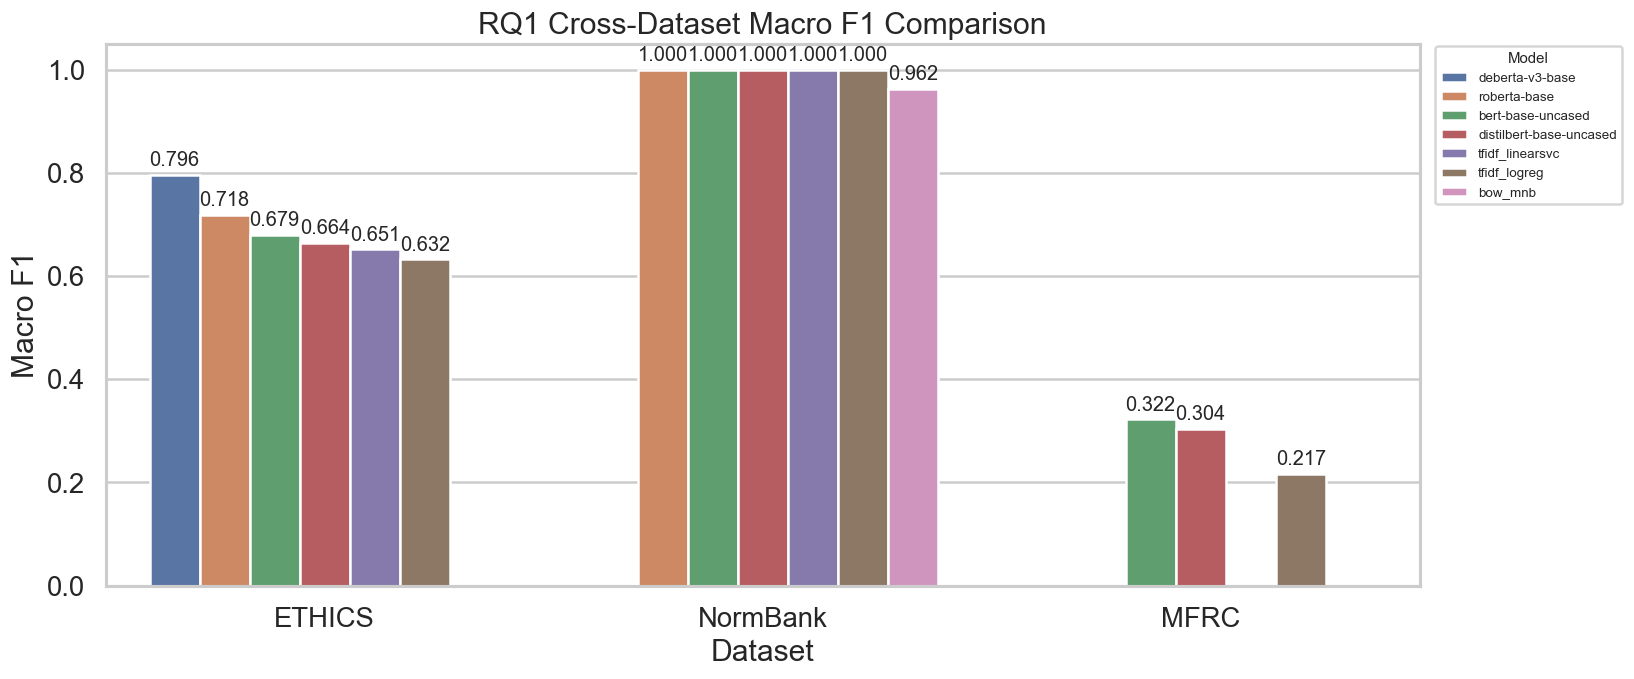

In [17]:
plot_frame = metrics_latest.copy()
plot_frame["dataset_label"] = pd.Categorical(
    plot_frame["dataset_label"],
    ["ETHICS", "NormBank", "MFRC"],
    ordered=True,
)

plt.figure(figsize=(15, 6))
ax = sns.barplot(data=plot_frame, x="dataset_label", y="macro_f1", hue="model_label")
ax.set_ylim(0, 1.05)
ax.set_title("RQ1 Cross-Dataset Macro F1 Comparison")
ax.set_xlabel("Dataset")
ax.set_ylabel("Macro F1")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=12)

plt.legend(
    title="Model",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    borderaxespad=0.2,
)

plt.tight_layout()
plt.subplots_adjust(right=0.80)
save_current_figure("rq1_cross_dataset_macro_f1")
plt.show()


Saved: results\figures\chapter8\rq1_cross_dataset_balanced_accuracy.png


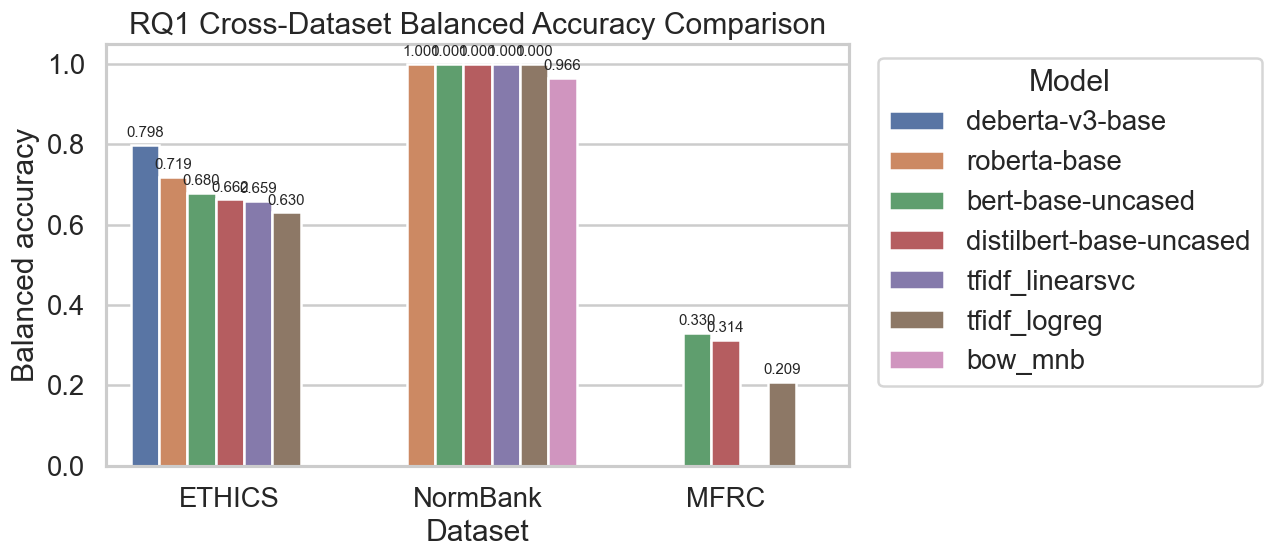

In [6]:
plt.figure(figsize=(11, 5))
ax = sns.barplot(data=plot_frame, x="dataset_label", y="balanced_accuracy", hue="model_label")
ax.set_ylim(0, 1.05)
ax.set_title("RQ1 Cross-Dataset Balanced Accuracy Comparison")
ax.set_xlabel("Dataset")
ax.set_ylabel("Balanced accuracy")
annotate_bars(ax)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
save_current_figure("rq1_cross_dataset_balanced_accuracy")
plt.show()


## Heatmaps

Saved: results\figures\chapter8\rq1_heatmap_accuracy.png


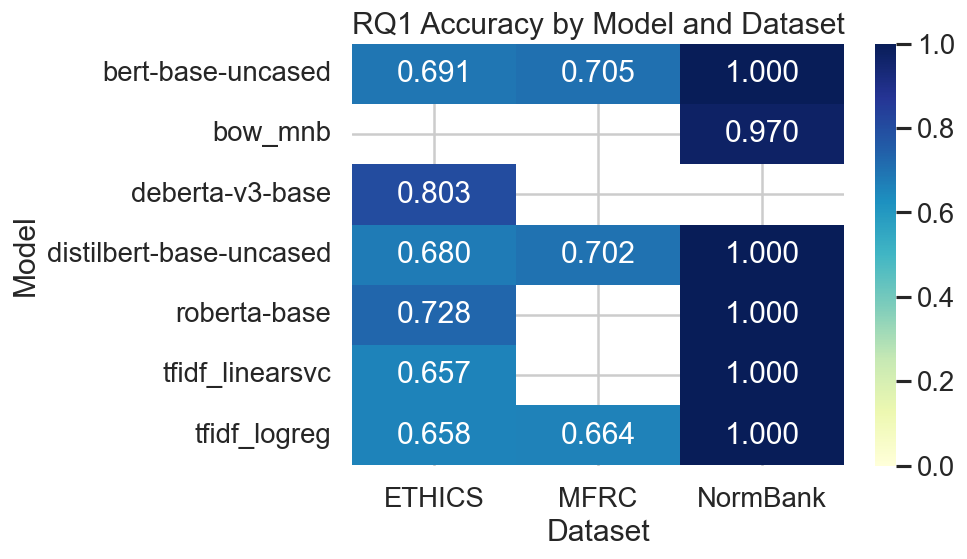

Saved: results\figures\chapter8\rq1_heatmap_macro_f1.png


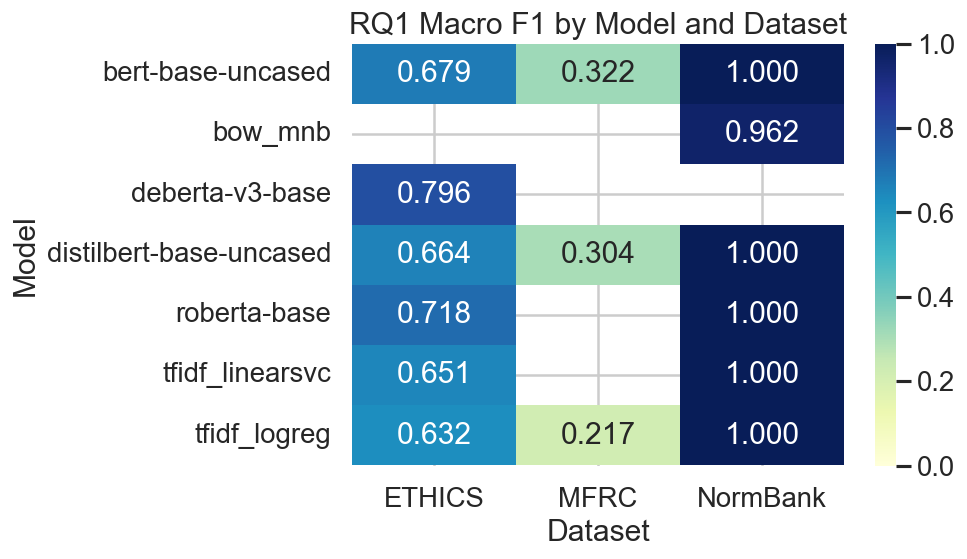

Saved: results\figures\chapter8\rq1_heatmap_balanced_accuracy.png


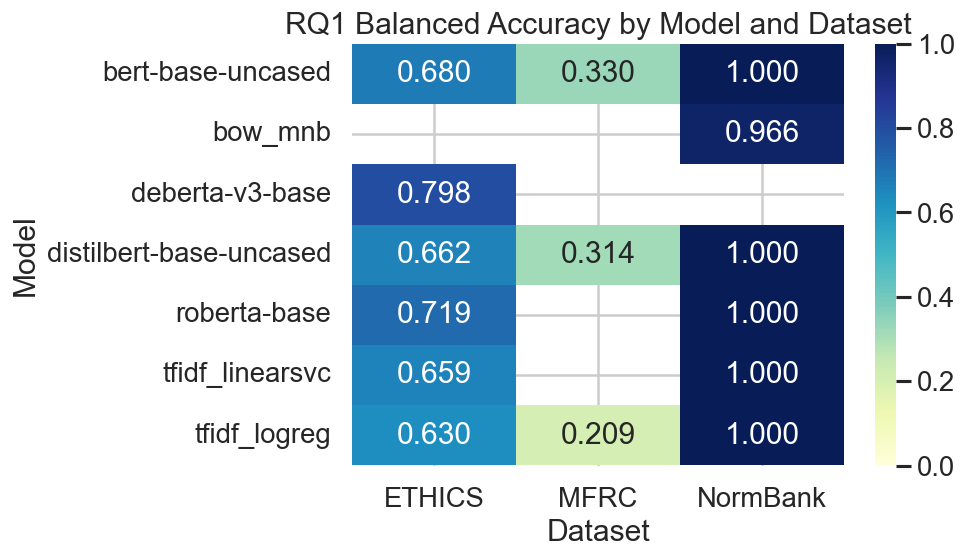

Saved: results\figures\chapter8\rq1_heatmap_mcc.png


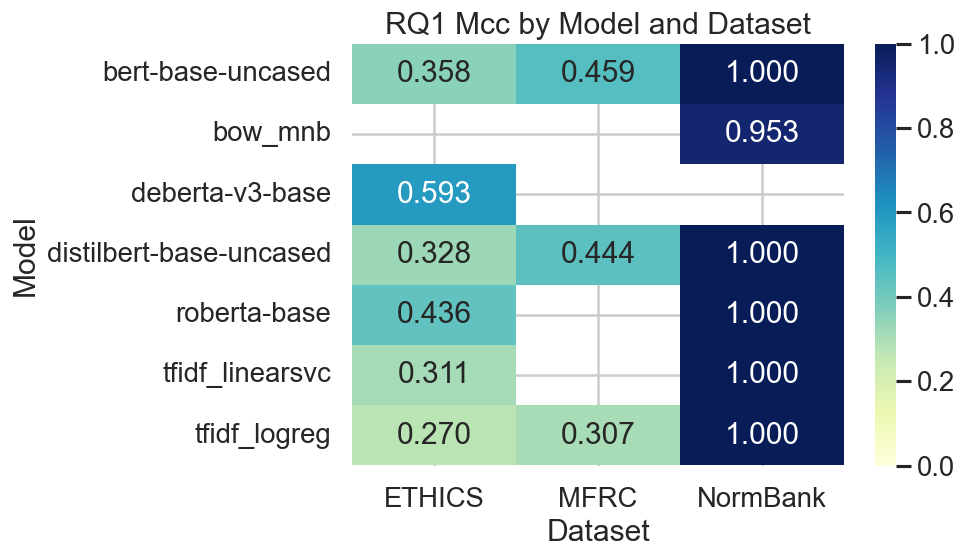

In [7]:
for metric in ["accuracy", "macro_f1", "balanced_accuracy", "mcc"]:
    pivot = metrics_latest.pivot(index="model_label", columns="dataset_label", values=metric)
    plt.figure(figsize=(8.5, 5))
    ax = sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1 if metric != "mcc" else None)
    ax.set_title(f"RQ1 {metric.replace('_', ' ').title()} by Model and Dataset")
    ax.set_xlabel("Dataset")
    ax.set_ylabel("Model")
    plt.tight_layout()
    save_current_figure(f"rq1_heatmap_{metric}")
    plt.show()


## Dataset-Specific Comparison Charts

Saved: results\figures\chapter8\rq1_ethics_macro_f1.png


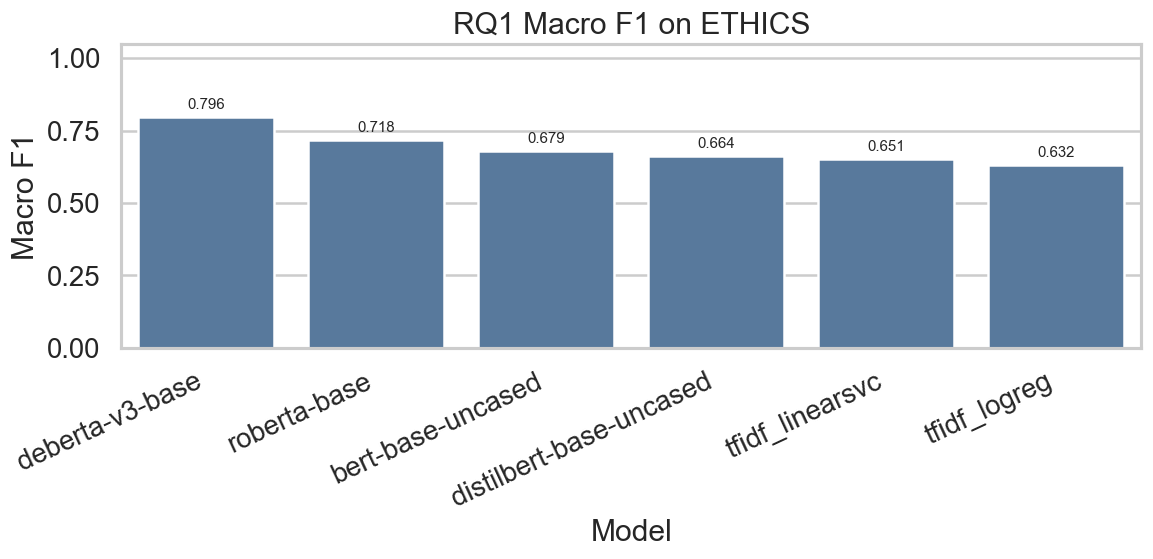

Saved: results\figures\chapter8\rq1_normbank_macro_f1.png


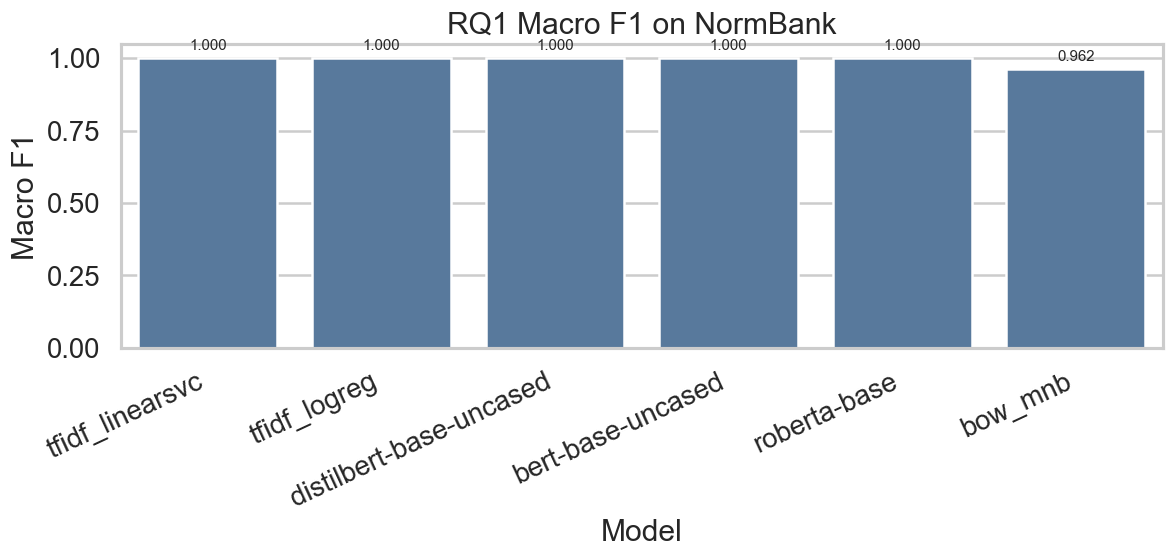

Saved: results\figures\chapter8\rq1_mfrc_macro_f1.png


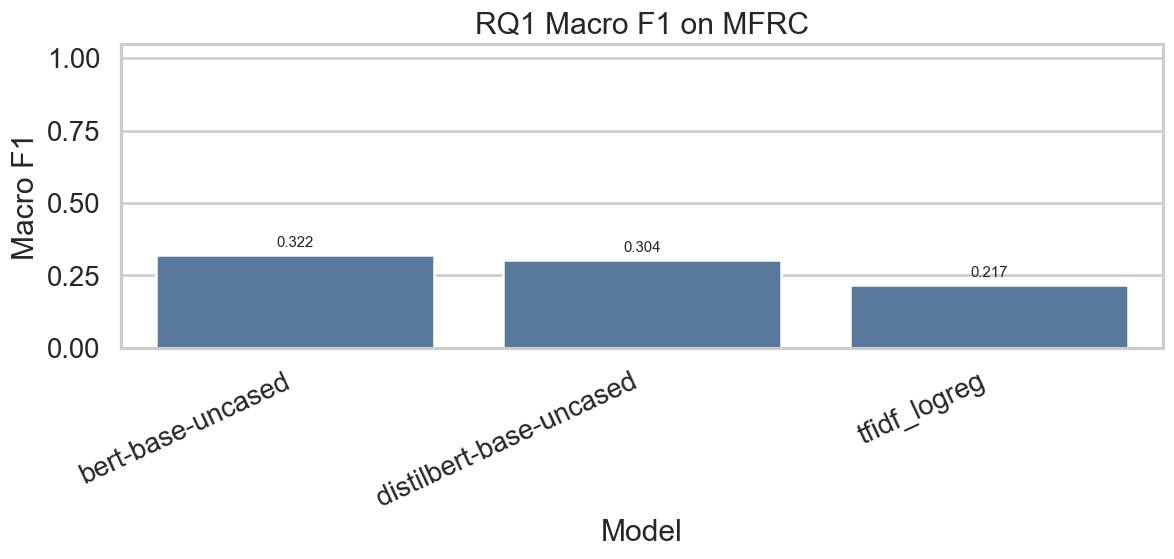

In [8]:
for dataset in ["ethics", "normbank", "mfrc"]:
    subset = metrics_latest[metrics_latest["dataset"] == dataset].sort_values("macro_f1", ascending=False).copy()
    label = tidy_dataset(dataset)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=subset, x="model_label", y="macro_f1", color="#4C78A8")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"RQ1 Macro F1 on {label}")
    ax.set_xlabel("Model")
    ax.set_ylabel("Macro F1")
    plt.xticks(rotation=25, ha="right")
    annotate_bars(ax)
    plt.tight_layout()
    save_current_figure(f"rq1_{dataset}_macro_f1")
    plt.show()


Saved: results\figures\chapter8\rq1_ethics_ece.png


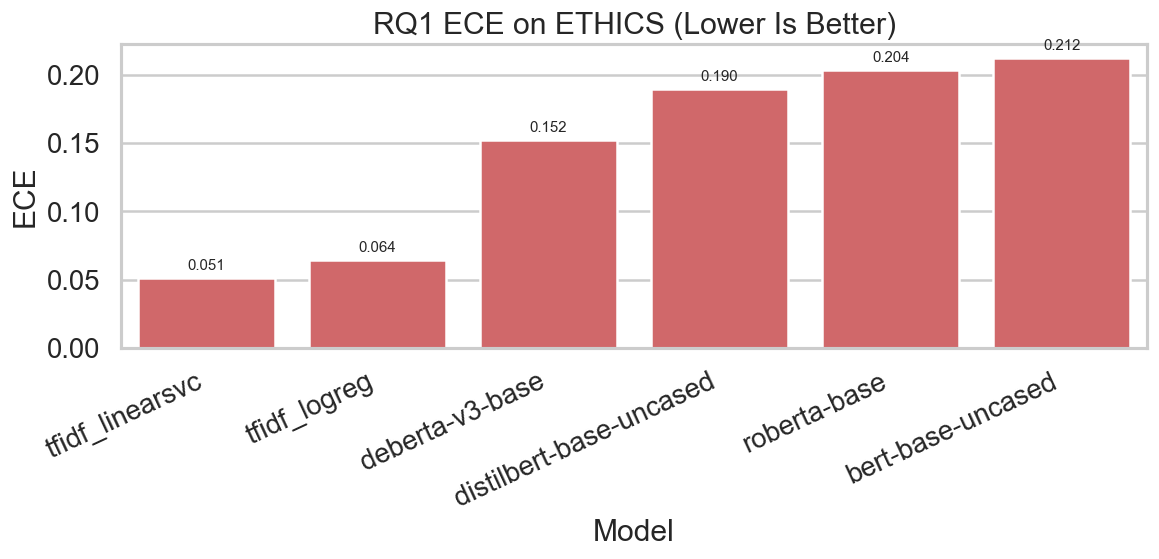

Saved: results\figures\chapter8\rq1_normbank_ece.png


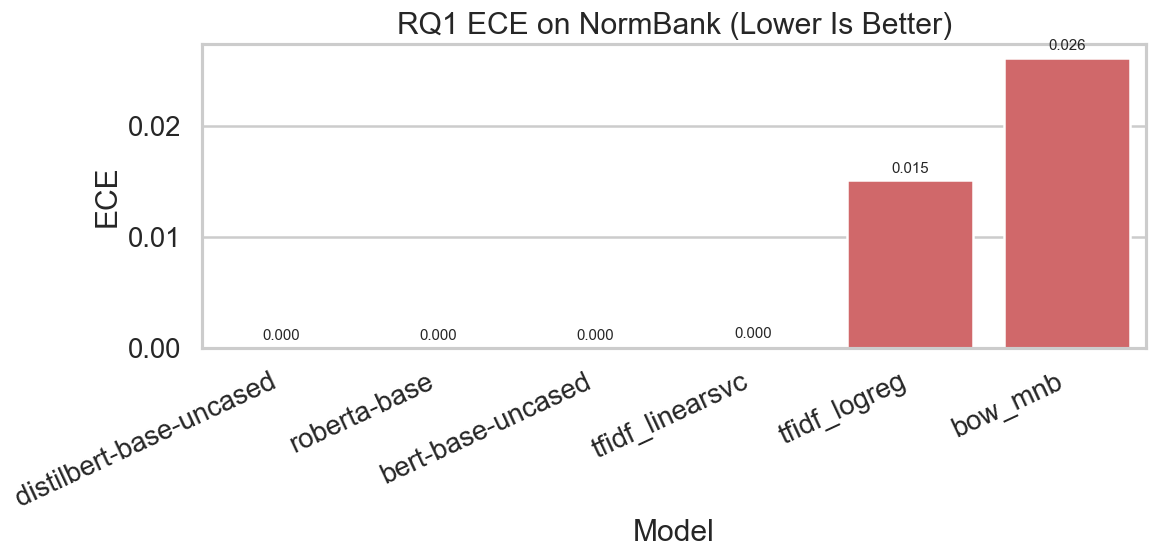

Saved: results\figures\chapter8\rq1_mfrc_ece.png


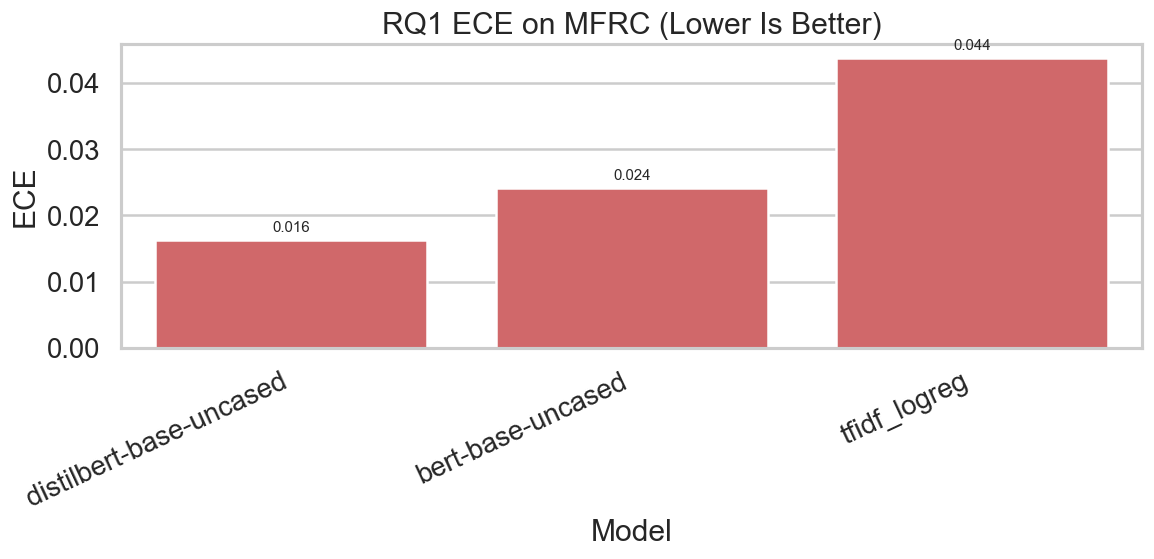

In [9]:
for dataset in ["ethics", "normbank", "mfrc"]:
    subset = metrics_latest[metrics_latest["dataset"] == dataset].sort_values("ece_10bin", ascending=True).copy()
    label = tidy_dataset(dataset)
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=subset, x="model_label", y="ece_10bin", color="#E15759")
    ax.set_title(f"RQ1 ECE on {label} (Lower Is Better)")
    ax.set_xlabel("Model")
    ax.set_ylabel("ECE")
    plt.xticks(rotation=25, ha="right")
    annotate_bars(ax)
    plt.tight_layout()
    save_current_figure(f"rq1_{dataset}_ece")
    plt.show()


## NormBank Caution Note

In [10]:
normbank_rows = metrics_latest[metrics_latest["dataset"] == "normbank"][['model_label', 'accuracy', 'macro_f1', 'balanced_accuracy', 'mcc']].copy()
display(normbank_rows)

print(
    "NormBank should be interpreted cautiously. In the processed benchmark form used here, the input text includes the norm-status phrase associated with the target label, which introduces likely label leakage. Near-perfect performance on NormBank is therefore likely inflated and should not be treated as genuine evidence of broad normative reasoning capability."
)


,model_label,accuracy,macro_f1,balanced_accuracy,mcc
9,tfidf_linearsvc,1.000000,1.000000,1.000000,1.000000
10,tfidf_logreg,1.000000,1.000000,1.000000,1.000000
11,distilbert-base-uncased,1.000000,1.000000,1.000000,1.000000
12,bert-base-uncased,1.000000,1.000000,1.000000,1.000000
13,roberta-base,1.000000,1.000000,1.000000,1.000000
14,bow_mnb,0.970119,0.961991,0.965648,0.952756


NormBank should be interpreted cautiously. In the processed benchmark form used here, the input text includes the norm-status phrase associated with the target label, which introduces likely label leakage. Near-perfect performance on NormBank is therefore likely inflated and should not be treated as genuine evidence of broad normative reasoning capability.


## Figure Inventory

In [ ]:
figure_files = sorted(FIGURES_DIR.glob("*.png"))
display(pd.DataFrame({
    "figure": [path.name for path in figure_files],
    "size_kb": [round(path.stat().st_size / 1024, 1) for path in figure_files],
}))
